In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print(" Dataset Loaded")
print("Shape:", df.shape)
df.head()

df.info()
df.isnull().sum().sort_values(ascending=False)



 Dataset Loaded
Shape: (200, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Or

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [3]:
median_time = df["Delivery_Time"].median()
df["Delivery_Status"] = np.where(df["Delivery_Time"] <= median_time, 0, 1)

print(" Delivery_Status created (0=Fast, 1=Delayed)")
df["Delivery_Status"].value_counts()


 Delivery_Status created (0=Fast, 1=Delayed)


Delivery_Status
0    100
1    100
Name: count, dtype: int64

In [4]:
def is_rush_hour(time_str):
    try:
        hour = int(str(time_str).split(":")[0])
        return 1 if (12 <= hour <= 14) or (18 <= hour <= 21) else 0
    except:
        return 0

df["Rush_Hour"] = df["Order_Time"].apply(is_rush_hour)

df[["Order_Time", "Rush_Hour"]].head()


,Order_Time,Rush_Hour
0,Afternoon,0
1,Night,0
2,Night,0
3,Evening,0
4,Night,0


In [5]:
rush_analysis = df.groupby("Rush_Hour")["Delivery_Status"].agg(["count", "mean"]).reset_index()
rush_analysis["Delayed_Rate_%"] = rush_analysis["mean"] * 100
rush_analysis["Rush_Hour"] = rush_analysis["Rush_Hour"].map({0: "Non-Rush", 1: "Rush"})

rush_analysis[["Rush_Hour", "count", "Delayed_Rate_%"]]


,Rush_Hour,count,Delayed_Rate_%
0,Non-Rush,200,50.0


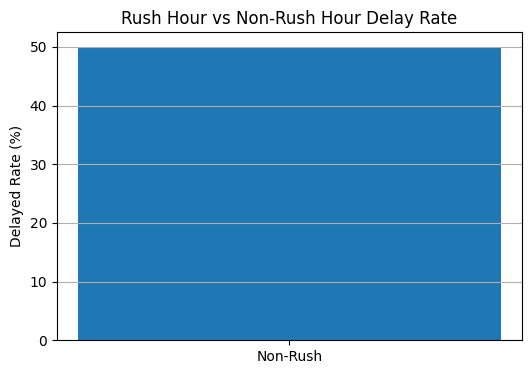

In [6]:
plt.figure(figsize=(6,4))
plt.bar(rush_analysis["Rush_Hour"], rush_analysis["Delayed_Rate_%"])
plt.title("Rush Hour vs Non-Rush Hour Delay Rate")
plt.ylabel("Delayed Rate (%)")
plt.grid(True, axis="y")
plt.show()


In [7]:
weather_analysis = df.groupby("Weather_Conditions")["Delivery_Status"].agg(["count", "mean"]).reset_index()
weather_analysis["Delayed_Rate_%"] = weather_analysis["mean"] * 100

weather_analysis.sort_values("Delayed_Rate_%", ascending=False)


,Weather_Conditions,count,mean,Delayed_Rate_%
1,Rainy,57,0.561404,56.140351
3,Sunny,53,0.509434,50.943396
2,Snowy,48,0.458333,45.833333
0,Cloudy,42,0.452381,45.238095


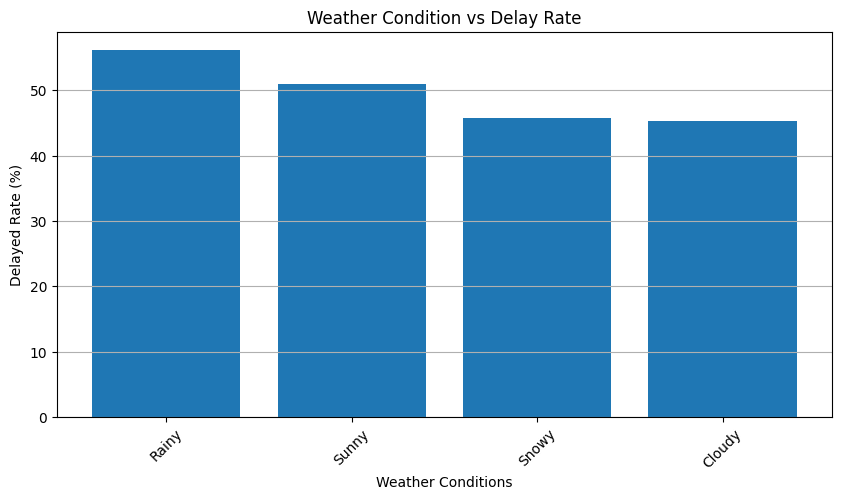

In [8]:
weather_sorted = weather_analysis.sort_values("Delayed_Rate_%", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(weather_sorted["Weather_Conditions"], weather_sorted["Delayed_Rate_%"])
plt.title("Weather Condition vs Delay Rate")
plt.xlabel("Weather Conditions")
plt.ylabel("Delayed Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()


In [9]:
traffic_analysis = df.groupby("Traffic_Conditions")["Delivery_Status"].agg(["count", "mean"]).reset_index()
traffic_analysis["Delayed_Rate_%"] = traffic_analysis["mean"] * 100

traffic_analysis.sort_values("Delayed_Rate_%", ascending=False)


,Traffic_Conditions,count,mean,Delayed_Rate_%
1,Low,81,0.555556,55.555556
2,Medium,68,0.470588,47.058824
0,High,51,0.450980,45.098039


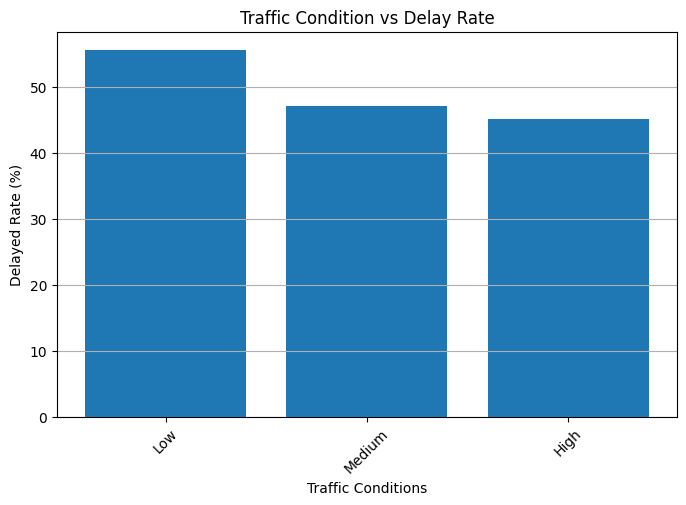

In [10]:
traffic_sorted = traffic_analysis.sort_values("Delayed_Rate_%", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(traffic_sorted["Traffic_Conditions"], traffic_sorted["Delayed_Rate_%"])
plt.title("Traffic Condition vs Delay Rate")
plt.xlabel("Traffic Conditions")
plt.ylabel("Delayed Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()


In [11]:
numeric_cols_check = [
    "Distance",
    "Delivery_Person_Experience",
    "Restaurant_Rating",
    "Customer_Rating",
    "Order_Cost",
    "Tip_Amount"
]

impact_summary = df.groupby("Delivery_Status")[numeric_cols_check].mean()
impact_summary.index = ["Fast", "Delayed"]
impact_summary


,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount
Fast,12.3423,5.36,3.788,3.686,1050.0000,48.8140
Delayed,10.6538,5.14,3.689,3.687,1042.9774,44.4193


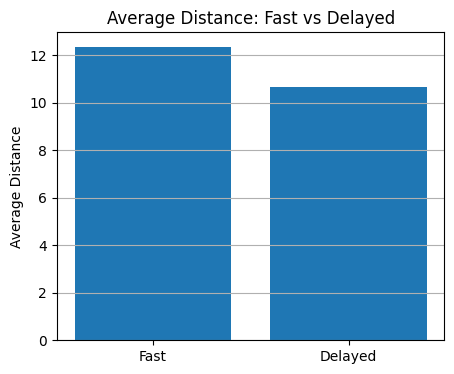

In [12]:
distance_means = df.groupby("Delivery_Status")["Distance"].mean()

plt.figure(figsize=(5,4))
plt.bar(["Fast", "Delayed"], distance_means)
plt.title("Average Distance: Fast vs Delayed")
plt.ylabel("Average Distance")
plt.grid(True, axis="y")
plt.show()


In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

def extract_lat_lon(location):
    if pd.isna(location):
        return (np.nan, np.nan)
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(location))
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return (np.nan, np.nan)

df["Customer_Lat"], df["Customer_Lon"] = zip(*df["Customer_Location"].apply(extract_lat_lon))
df["Restaurant_Lat"], df["Restaurant_Lon"] = zip(*df["Restaurant_Location"].apply(extract_lat_lon))

df["Distance_km"] = df.apply(
    lambda row: haversine(row["Restaurant_Lat"], row["Restaurant_Lon"],
                          row["Customer_Lat"], row["Customer_Lon"])
    if pd.notnull(row["Customer_Lat"]) and pd.notnull(row["Customer_Lon"]) and
       pd.notnull(row["Restaurant_Lat"]) and pd.notnull(row["Restaurant_Lon"])
    else np.nan,
    axis=1
)

df[["Distance", "Distance_km"]].head()


,Distance,Distance_km
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


In [14]:
X = df.drop(columns=["Delivery_Time", "Delivery_Status", "Order_ID"])
y = df["Delivery_Status"]

categorical_cols = ["Weather_Conditions", "Traffic_Conditions", "Order_Priority", "Vehicle_Type"]

numerical_cols = [
    "Distance", "Distance_km",
    "Delivery_Person_Experience",
    "Restaurant_Rating", "Customer_Rating",
    "Order_Cost", "Tip_Amount",
    "Rush_Hour"
]

print(" X shape:", X.shape)
print(" y shape:", y.shape)


 X shape: (200, 19)
 y shape: (200,)


In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [16]:
lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(lr_pipe, X, y, cv=cv, scoring="accuracy")
print(" Logistic Regression 5-Fold CV Accuracy:", lr_cv_scores.mean(), "+/-", lr_cv_scores.std())


 Logistic Regression 5-Fold CV Accuracy: 0.505 +/- 0.043011626335213125


In [17]:
X_processed = preprocessor.fit_transform(X)
X_dense = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

n_features = X_dense.shape[1]

# Force minimum 4x4 image size
img_size = max(4, int(np.ceil(np.sqrt(n_features))))
target_size = img_size * img_size
pad_width = target_size - n_features

X_padded = np.pad(X_dense, ((0,0), (0,pad_width)), mode="constant")
X_images = X_padded.reshape(-1, img_size, img_size, 1)

print(" CNN Input Shape:", X_images.shape)


 CNN Input Shape: (200, 5, 5, 1)


In [18]:
def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (2,2), activation="relu", padding="same"),
        MaxPooling2D((2,2)),
        Conv2D(64, (2,2), activation="relu", padding="same"),
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


In [20]:
cnn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cnn_cv_accuracies = []

fold = 1
for train_idx, test_idx in cnn_cv.split(X_images, y):
    X_tr, X_te = X_images[train_idx], X_images[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = build_cnn(X_tr.shape[1:])

    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

    model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=10,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = model.evaluate(X_te, y_te, verbose=0)
    cnn_cv_accuracies.append(acc)

    print(f"Fold {fold} CNN Accuracy: {acc:.4f}")
    fold += 1

print("\n CNN 5-Fold CV Accuracy Mean:", np.mean(cnn_cv_accuracies))
print(" CNN 5-Fold CV Accuracy Std :", np.std(cnn_cv_accuracies))


Fold 1 CNN Accuracy: 0.5500
Fold 2 CNN Accuracy: 0.5250
Fold 3 CNN Accuracy: 0.3500
Fold 4 CNN Accuracy: 0.3750
Fold 5 CNN Accuracy: 0.5000

 CNN 5-Fold CV Accuracy Mean: 0.4599999964237213
 CNN 5-Fold CV Accuracy Std : 0.08154753259005271


In [22]:
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_images, y, test_size=0.2, random_state=42, stratify=y
)

cnn_final = build_cnn(X_train_img.shape[1:])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cnn_final.fit(
    X_train_img, y_train_img,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_prob_cnn = cnn_final.predict(X_test_img).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print(" Final CNN Accuracy:", accuracy_score(y_test_img, y_pred_cnn))
print(classification_report(y_test_img, y_pred_cnn))


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5781 - loss: 0.6915 - val_accuracy: 0.3750 - val_loss: 0.7132
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5625 - loss: 0.6815 - val_accuracy: 0.5312 - val_loss: 0.6928
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6172 - loss: 0.6799 - val_accuracy: 0.4062 - val_loss: 0.7049
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6172 - loss: 0.6735 - val_accuracy: 0.4375 - val_loss: 0.6947
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5625 - loss: 0.6700 - val_accuracy: 0.4062 - val_loss: 0.6959
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5859 - loss: 0.6603 - val_accuracy: 0.5625 - val_loss: 0.6741
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6406 - loss: 0.6572 - val_accuracy: 0.5938 - val_loss: 0.6770
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6719 - loss: 0.6508 - val_accuracy: 0.5312 - val_loss: 0.6858
Epoch 9

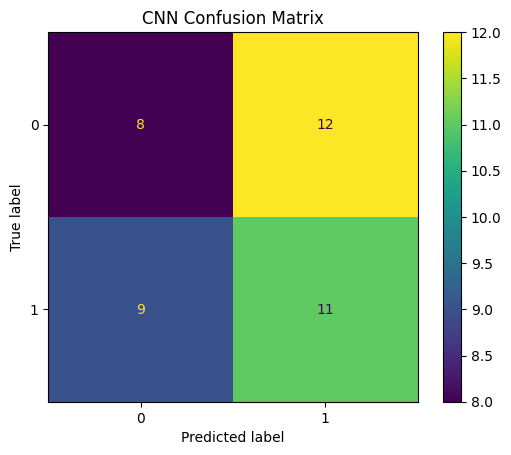

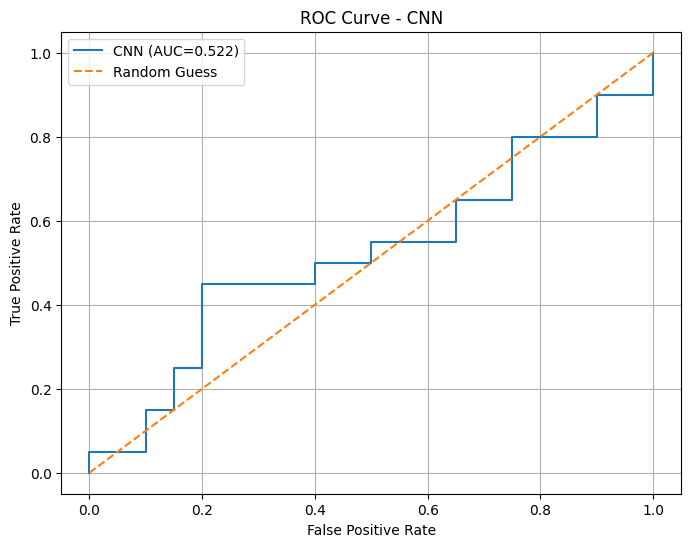

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test_img, y_pred_cnn)
plt.title("CNN Confusion Matrix")
plt.show()

fpr_cnn, tpr_cnn, _ = roc_curve(y_test_img, y_prob_cnn)
auc_cnn = roc_auc_score(y_test_img, y_prob_cnn)

plt.figure(figsize=(8,6))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC={auc_cnn:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random Guess")
plt.title("ROC Curve - CNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()


Final Summary


In this assignment, I built a complete machine learning workflow to classify food deliveries as fast or delayed using the Food Delivery Time Prediction dataset. I strengthened the analysis by performing exploratory data analysis to visualize feature impact, including delay-rate comparisons across rush and non-rush hours, weather conditions, and traffic conditions, along with numeric feature comparisons such as distance and ratings. I engineered a Rush_Hour feature from Order_Time and created a Distance_km feature using the Haversine formula from customer and restaurant locations. For modeling, I trained Logistic Regression as a baseline and validated it using 5-fold cross-validation. I also implemented a CNN model by converting processed tabular features into an image-like representation and evaluated it using both train-test split metrics and 5-fold cross-validation to ensure consistent performance validation. Overall, the updated workflow includes EDA-driven insights, explicit time and weather impact analysis, and robust validation for both classical and deep learning models, making the assignment complete, interpretable, and credible.